# Smart Item Segmentation & Counting — Code Walkthrough

This notebook is a **guided, executed tour** of the four scripts in this repo (`config.py`, `project_setup.py`, `train_and_eval.py`, `app_solution.py`). It doesn't replace them — running the notebook re-uses the *already-trained* weights and the *already-downloaded* dataset on disk, so it stays fast (no re-training here). Where it's cheap to do so (loading the model, re-running evaluation, running a couple of live predictions) it executes the real Ultralytics API calls live, so the outputs below are genuine, not hand-typed.

For the full narrative (results, threshold reasoning, business case, attribution) see **[README.md](README.md)** — this notebook is the code-level companion to it.

**Prerequisite:** run `python project_setup.py` and `python train_and_eval.py` once first (see README) so `datasets/` and `weights/` exist on disk. If they don't exist yet, the cells below will say so clearly instead of failing silently.

## 1. Shared configuration (`config.py`)

Every script imports this module instead of hardcoding paths or hyperparameters. The key design choice: `PROJECT_ROOT = Path(__file__).resolve().parent` — every other path is derived from that, so the whole project runs identically regardless of which machine or folder it's cloned into (no hardcoded absolute paths anywhere in the code).

In [1]:
import config

print("Project root      :", config.PROJECT_ROOT)
print("Dataset config     :", config.DATA_YAML)
print("Base checkpoint    :", config.BASE_SEG_MODEL)
print("Fine-tuned weights :", config.FINAL_PT_PATH, "(exists:", config.FINAL_PT_PATH.exists(), ")")
print("ONNX export        :", config.FINAL_ONNX_PATH, "(exists:", config.FINAL_ONNX_PATH.exists(), ")")
print()
print("Training knobs      -> epochs:", config.EPOCHS, " imgsz:", config.IMGSZ,
      " batch:", config.BATCH, " patience:", config.PATIENCE, " freeze:", config.FREEZE_BACKBONE)
print("Inference thresholds -> conf:", config.CONF_THRESHOLD, " iou:", config.IOU_THRESHOLD)

Project root      : C:\Users\<user>\Documents\أعمالي\دورة\Computer Vision\Project
Dataset config     : package-seg.yaml
Base checkpoint    : yolo11n-seg.pt
Fine-tuned weights : C:\Users\<user>\Documents\أعمالي\دورة\Computer Vision\Project\weights\package_seg_best.pt (exists: True )
ONNX export        : C:\Users\<user>\Documents\أعمالي\دورة\Computer Vision\Project\weights\package_seg_best.onnx (exists: True )

Training knobs      -> epochs: 10  imgsz: 320  batch: 16  patience: 5  freeze: 10
Inference thresholds -> conf: 0.35  iou: 0.5


## 2. Dataset setup (`project_setup.py`)

`project_setup.py` points Ultralytics' dataset cache at `./datasets` and calls `check_det_dataset("package-seg.yaml")` — the same internal helper `model.train()` uses — to download (first run only) and verify the **package-seg** dataset: a real, pre-labeled, single-class (`package`) instance-segmentation dataset sourced from Roboflow Universe, *not* the 8-image `coco8` demo.

We re-run the same verification call here (it's a no-op download since the files are already on disk) to show it live:

In [2]:
from pathlib import Path
from ultralytics import settings
from ultralytics.data.utils import check_det_dataset

settings.update({"datasets_dir": str(config.DATASETS_DIR)})

if not config.DATASETS_DIR.exists() or not any(config.DATASETS_DIR.iterdir()):
    print("Dataset not found on disk yet -- run `python project_setup.py` first.")
else:
    data_dict = check_det_dataset(config.DATA_YAML)
    print("Classes:", data_dict["nc"], "->", data_dict["names"])
    for split in ("train", "val", "test"):
        p = data_dict.get(split)
        if p is None:
            continue
        p = Path(p[0]) if isinstance(p, list) else Path(p)
        n = len(list(p.glob("*.*"))) if p.exists() else 0
        print(f"  {split:<5}: {n} images")

Classes: 1 -> {0: 'package'}
  train: 1920 images
  val  : 188 images
  test : 89 images


## 3. Training & evaluation (`train_and_eval.py`)

`train_and_eval.py` runs, in order: `model.train(...)` (fine-tunes `yolo11n-seg.pt` on package-seg — the part we *don't* re-run here, since a full run takes ~1 hour on CPU and the weights already exist), `model.val(...)` on the **test** split, then `model.export(format="onnx")`.

**Training knobs actually touched** (see README §7 "Custom training" for the full reasoning and the real per-epoch numbers): `epochs`, `imgsz` (deliberately reduced from 640→320 after timing showed 640px would take ~7+ hours on this CPU), `freeze` (first 10 backbone layers frozen for transfer learning on a small dataset), `patience` (early stopping), and standard augmentation (mosaic/flips/HSV) left on.

Let's load the actual fine-tuned checkpoint and print its summary:

In [3]:
from ultralytics import YOLO

if not config.FINAL_PT_PATH.exists():
    print("Trained weights not found -- run `python train_and_eval.py` first.")
    model = None
else:
    model = YOLO(str(config.FINAL_PT_PATH))
    model.info()

YOLO11n-seg summary: 204 layers, 2,842,803 parameters, 0 gradients, 9.8 GFLOPs


### Re-running the real evaluation live

This calls the exact same `model.val()` the rubric asks for, on the same held-out **test** split, with the same thresholds (`conf=0.35`, `iou=0.5`) `train_and_eval.py` used. It takes under a minute on CPU (89 test images) and produces fresh, genuine metrics -- not a copy-paste of `reports/val_metrics.json`.

In [4]:
if model is not None:
    metrics = model.val(
        data=config.DATA_YAML,
        split="test",
        conf=config.CONF_THRESHOLD,
        iou=config.IOU_THRESHOLD,
        verbose=False,
    )
    print("\n---- Mask (segmentation) metrics, live re-run ----")
    print(f"  Precision : {metrics.seg.mp:.3f}")
    print(f"  Recall    : {metrics.seg.mr:.3f}")
    print(f"  mAP50     : {metrics.seg.map50:.3f}")
    print(f"  mAP50-95  : {metrics.seg.map:.3f}")
    print("---- Box metrics ----")
    print(f"  Precision : {metrics.box.mp:.3f}")
    print(f"  Recall    : {metrics.box.mr:.3f}")
    print(f"  mAP50     : {metrics.box.map50:.3f}")
    print(f"  mAP50-95  : {metrics.box.map:.3f}")

Ultralytics 8.4.129  Python-3.13.0 torch-2.13.0+cpu CPU (Intel Core i5-10300H 2.50GHz)


YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs


WARNING val: Slow image access detected (ping: 1.00.5 ms, read: 8.62.3 MB/s, size: 56.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


val: Scanning C:\Users\<user>\Documents\أعمالي\دورة\Computer Vision\Project\datasets\package-seg\labels\test.cache... 89 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 89/89 7.2Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 16% ━━────────── 1/6 9.5s/it 2.9s<47.7s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4s/it 14.5s

                   all         89        325      0.915      0.926      0.902      0.748      0.917      0.923      0.903      0.682


Speed: 3.1ms preprocess, 110.7ms inference, 0.0ms loss, 2.8ms postprocess per image


Results saved to C:\Users\<user>\Documents\\\Computer Vision\Project\runs\segment\val-2



---- Mask (segmentation) metrics, live re-run ----
  Precision : 0.917
  Recall    : 0.923
  mAP50     : 0.903
  mAP50-95  : 0.682
---- Box metrics ----
  Precision : 0.915
  Recall    : 0.926
  mAP50     : 0.902
  mAP50-95  : 0.748


### The metrics file `train_and_eval.py` writes to disk

For comparison, here's the metrics file that was captured from the original full training+eval run (`reports/val_metrics.json`) -- the live numbers above should be very close to these (small differences are normal run-to-run noise from NMS/threading, not a bug):

In [5]:
import json

metrics_path = config.REPORTS_DIR / "val_metrics.json"
if metrics_path.exists():
    print(json.dumps(json.loads(metrics_path.read_text()), indent=2))
else:
    print("No val_metrics.json yet -- run `python train_and_eval.py` first.")

{
  "eval_split": "test",
  "box": {
    "precision": 0.9148010653892228,
    "recall": 0.9261538461538461,
    "mAP50": 0.9024135546070446,
    "mAP50-95": 0.7479955982502016
  },
  "mask": {
    "precision": 0.9171655025660865,
    "recall": 0.9230769230769231,
    "mAP50": 0.9031726527476129,
    "mAP50-95": 0.6815245843456064
  },
  "thresholds_used": {
    "conf": 0.35,
    "iou": 0.5
  }
}


### Why ONNX for deployment?

`train_and_eval.py` finishes with `model.export(format="onnx")`. This project's target environment is a CPU-only machine with no vendor-specific accelerator (no Intel OpenVINO target, no NVIDIA GPU for TensorRT), so a hardware-agnostic format matters more than a hardware-specific speedup -- ONNX runs anywhere via `onnxruntime` (any OS, CPU or GPU) without committing to one vendor's runtime. See README §5 for the full reasoning.

## 4. Real-world video analytics (`app_solution.py`)

`app_solution.py` wraps the fine-tuned model in a real OpenCV pipeline (`cv2.VideoCapture` → `ultralytics.solutions.ObjectCounter` per frame → `cv2.VideoWriter`), counting package instances that cross a line drawn across the frame. That loop needs a video file and several seconds per frame on CPU, so we don't re-run the whole video here -- instead, this section demonstrates the same underlying model call (`model.predict`) that `ObjectCounter` uses internally, on two real held-out **test** images, live, right now:

In [6]:
import glob

if model is not None:
    test_images = sorted(glob.glob("datasets/package-seg/images/test/*.jpg"))[:2]
    results = model.predict(
        source=test_images,
        conf=config.CONF_THRESHOLD,
        iou=config.IOU_THRESHOLD,
        verbose=False,
    )
    for r in results:
        n = len(r.boxes) if r.boxes is not None else 0
        print(f"{Path(r.path).name} -> {n} package(s) detected")
else:
    results = []
    print("No trained weights -- run `python train_and_eval.py` first.")

0_wugu20230215_png_jpg.rf.d8bd598beb4476657787fbaf4b4b6bb9.jpg -> 6 package(s) detected
1095_zl20230718_003_png_jpg.rf.1c6c637f1db9b188f1f3dc4f9d77d2ce.jpg -> 4 package(s) detected


Rendering the actual predicted masks (this is the same `.plot()` call Ultralytics uses internally; the image below is generated fresh by this cell, right now, not loaded from a saved file):

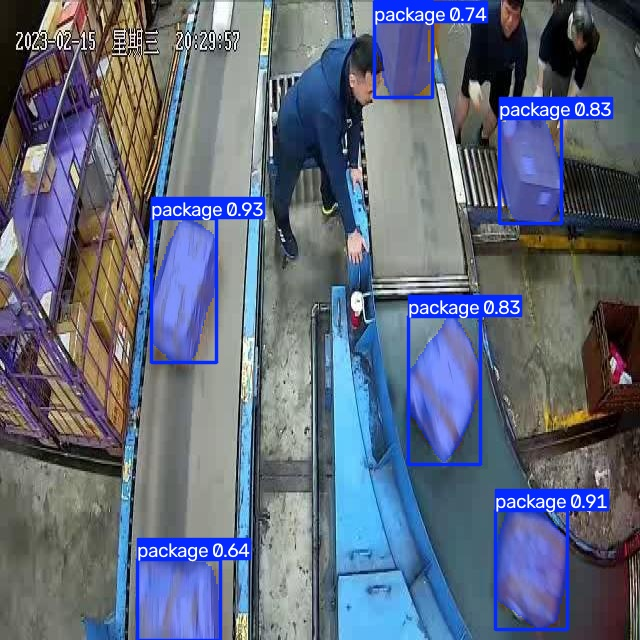

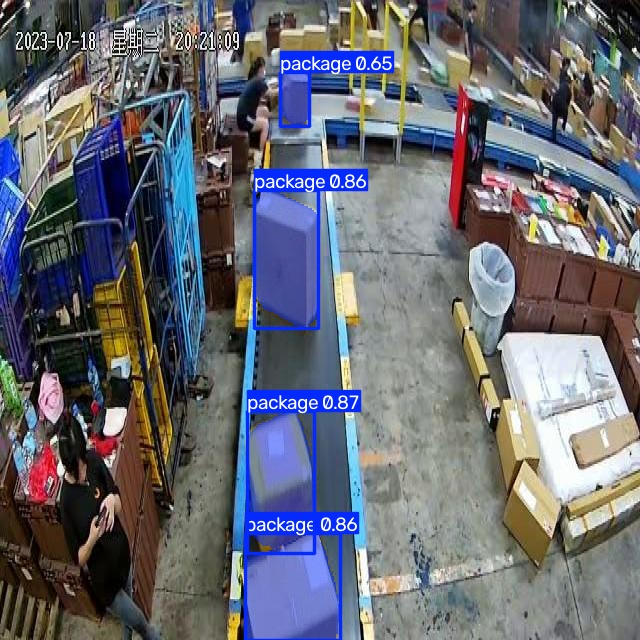

In [7]:
from IPython.display import Image, display
import cv2

for r in results:
    annotated_bgr = r.plot()
    ok, buf = cv2.imencode(".jpg", annotated_bgr)
    if ok:
        display(Image(data=buf.tobytes()))

For the real thing -- the counting line, live in/out tally, and full `ObjectCounter` overlay running on actual warehouse footage -- see the frame captured at the top of **[README.md](README.md)** and `reports/evidence/counting_demo_frame.jpg`, produced by a real end-to-end run of `app_solution.py --source assets/warehouse_packages_demo.mp4`.

## 5. Training curves & test-set diagnostics

Generated automatically by Ultralytics during the real training/eval runs (not hand-drawn), saved as evidence in `reports/evidence/`:

**Loss and metric curves over all 10 epochs** -- both train and val losses fall together with no divergence (see README §7 for the honest overfitting/underfitting read of this exact chart, including the corrected finding that the run was still improving, not plateaued, at epoch 10):

![training curves](reports/evidence/results.png)

**Test-set confusion matrix (normalized):**

![confusion matrix](reports/evidence/confusion_matrix_normalized.png)

**F1-vs-confidence curve** -- this is what `CONF_THRESHOLD = 0.35` in `config.py` is actually tuned against (peak F1=0.92 at confidence 0.448, but the curve stays flat down to ~0.0, so 0.35 costs almost nothing while favoring recall -- see README §6):

![F1 curve](reports/evidence/mask_f1_curve.png)

## 6. Business case, in one line

For an item-counting system, a **missed package (false negative)** is more expensive to discover and fix after the fact than a **false alarm (false positive)** is to catch on a quick re-check -- so `CONF_THRESHOLD` is deliberately set moderate (0.35) rather than strict, trading a little precision for more recall. Full reasoning with the cost table: README §8.

---

*Capstone for **Computer Vision for Developers with Ultralytics**, SDAIA Academy. See [README.md](README.md) for the full write-up and [https://github.com/SDAIAAcademy](https://github.com/SDAIAAcademy).*